# 📊 Data Drift — Evidently AI + Analyses Complémentaires
## Portefeuille Assurance

Ce notebook utilise **Evidently AI** (v0.7+) comme moteur principal de détection du drift, complété par des analyses statistiques et des visualisations métier.

### Architecture du notebook

| Section | Outil | Description |
|---|---|---|
| 1–3 | Setup | Chargement, feature engineering, split baseline/current |
| 4 | **Evidently Report** | DataDriftPreset + DataSummaryPreset — rapport HTML interactif |
| 5 | **Evidently Metrics** | ValueDrift, DriftedColumnsCount, statistiques par colonne |
| 6 | **Evidently par trimestre** | Drift glissant — un rapport Evidently par période |
| 7 | Analyses complémentaires | PSI manuel, KDE, Chi² catégoriel |
| 8 | KPIs métier | Évolution temporelle (primes, sinistres, états) |
| 9 | Dashboard synthèse | Heatmap + alertes |
| 10 | Export | HTML Evidently + CSV résultats |

> **Versions :** `evidently>=0.7` — API `Dataset` / `DataDefinition` / `Report`


## 1. Imports & Configuration

In [222]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.spatial.distance import jensenshannon
from pathlib import Path
import os, json

# ── Evidently AI ──────────────────────────────────────────────────────────
import evidently
from evidently import Dataset, DataDefinition, Report
from evidently.presets  import DataDriftPreset, DataSummaryPreset
from evidently.metrics  import (
    ValueDrift, DriftedColumnsCount,
    MeanValue, StdValue, MinValue, MaxValue, MedianValue, QuantileValue,
    DatasetMissingValueCount, MissingValueCount,
    RowCount, ColumnCount, UniqueValueCount
)

print(f"Evidently version : {evidently.__version__}")

# ── Style ─────────────────────────────────────────────────────────────────
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#1976D2', '#D32F2F', '#388E3C', '#F57C00', '#7B1FA2', '#0097A7']
sns.set_palette(PALETTE)

# PSI thresholds (complémentaires à Evidently)
PSI_STABLE   = 0.10
PSI_MODERATE = 0.20

def psi_level(v):
    if   v < PSI_STABLE:   return '✅ Stable',   '#4CAF50'
    elif v < PSI_MODERATE: return '⚠️ Modéré',   '#FF9800'
    else:                   return '🚨 Critique',  '#F44336'

print("✅ Tous les imports OK")


Evidently version : 0.7.21
✅ Tous les imports OK


## 2. Chargement des Données

In [223]:
DATA_PATH = Path("C:/Users/LENOVO/Desktop/PFE_/maghrebia/data/raw")   # ← adapter si besoin

def load(name):
    return pd.read_csv(DATA_PATH / f"{name}.csv", low_memory=False)

emission   = load("DWH_FACT_EMISSION")
sinistre   = load("DWH_FACT_SINISTRE")
impaye     = load("DWH_FACT_IMPAYE")
police     = load("DIM_POLICE")
client     = load("DIM_CLIENT")

# ── Parsing dates ─────────────────────────────────────────────────────────
for col in ['DATE_EMISSION', 'DATE_EFFET', 'DATE_ECHEANCE']:
    emission[col] = pd.to_datetime(emission[col], errors='coerce')
sinistre['DATE_SURVENANCE'] = pd.to_datetime(sinistre['DATE_SURVENANCE'], errors='coerce')
impaye['DATE_EMISSION']     = pd.to_datetime(impaye['DATE_EMISSION'],     errors='coerce')

print("Données chargées :")
for name, df in [("EMISSION", emission), ("SINISTRE", sinistre),
                 ("IMPAYE",   impaye),   ("POLICE",   police)]:
    print(f"  {name:<12} : {len(df):>7,} lignes  ×  {df.shape[1]} colonnes")


Données chargées :
  EMISSION     :  65,000 lignes  ×  33 colonnes
  SINISTRE     :   8,000 lignes  ×  16 colonnes
  IMPAYE       :     868 lignes  ×  16 colonnes
  POLICE       :  30,000 lignes  ×  16 colonnes


## 3. Feature Engineering & Split Temporel

In [224]:
# ── Features dérivées ────────────────────────────────────────────────────
mt_cols = [c for c in emission.columns if c.startswith('MT_')]
emission['MT_TOTAL']              = emission[mt_cols].fillna(0).sum(axis=1)
emission['MT_PNET']               = emission['MT_PNET'].fillna(0)
emission['RATIO_COMMISSION']      = (
    emission['MT_COMMISSION'].fillna(0) / emission['MT_PNET'].replace(0, np.nan)
)
emission['DELAI_EMISSION_JOURS']  = (
    emission['DATE_EMISSION'] - emission['DATE_EFFET']
).dt.days

emission['ANNEE']      = emission['DATE_EMISSION'].dt.year
emission['TRIMESTRE']  = emission['DATE_EMISSION'].dt.to_period('Q').astype(str)
emission['ANNEE_MOIS'] = emission['DATE_EMISSION'].dt.to_period('M')

# ── Split baseline / current ─────────────────────────────────────────────
years = sorted(emission['ANNEE'].dropna().unique())
mid   = len(years) // 2
baseline_years = list(years[:mid])
current_years  = list(years[mid:])

df_baseline = emission[emission['ANNEE'].isin(baseline_years)].copy()
df_current  = emission[emission['ANNEE'].isin(current_years)].copy()

print(f"Années disponibles  : {years}")
print(f"Baseline (référence): {baseline_years} → {len(df_baseline):>7,} lignes")
print(f"Current  (actuelle) : {current_years}  → {len(df_current):>7,} lignes")


Années disponibles  : [2017.0, 2018.0, 2019.0, 2020.0, 2021.0, 2022.0, 2023.0, 2024.0, 2025.0]
Baseline (référence): [2017.0, 2018.0, 2019.0, 2020.0] →  23,125 lignes
Current  (actuelle) : [2021.0, 2022.0, 2023.0, 2024.0, 2025.0]  →  40,502 lignes


## 4. Rapport Evidently — DataDrift + DataSummary

Evidently génère un rapport HTML interactif complet. Nous l'affichons aussi inline dans le notebook.


In [225]:
# ── Features à surveiller ────────────────────────────────────────────────
NUMERICAL_FEATURES = [
    'MT_PNET', 'MT_TOTAL', 'MT_COMMISSION',
    'RATIO_COMMISSION', 'BONUS_MALUS', 'DELAI_EMISSION_JOURS',
]
CATEGORICAL_FEATURES = ['BRANCHE', 'PERIODICITE', 'ETAT_QUIT']

ALL_FEATURES = NUMERICAL_FEATURES + CATEGORICAL_FEATURES

# Préparer les DataFrames avec uniquement les colonnes d'intérêt
ref_df = df_baseline[ALL_FEATURES].copy().reset_index(drop=True)
cur_df = df_current[ALL_FEATURES].copy().reset_index(drop=True)

# Nettoyage minimal
for col in NUMERICAL_FEATURES:
    ref_df[col] = pd.to_numeric(ref_df[col], errors='coerce')
    cur_df[col] = pd.to_numeric(cur_df[col], errors='coerce')

print(f"Référence : {ref_df.shape}  |  Actuel : {cur_df.shape}")
ref_df.head(3)


Référence : (23125, 9)  |  Actuel : (40502, 9)


,MT_PNET,MT_TOTAL,MT_COMMISSION,RATIO_COMMISSION,BONUS_MALUS,DELAI_EMISSION_JOURS,BRANCHE,PERIODICITE,ETAT_QUIT
0,153.0710,569.3550,29.4700,0.1925,7.0000,-24.0000,AUTO,S,P
1,106.5790,354.4570,14.4720,0.1358,NaN,-27.0000,IRDS,A,P
2,223.6080,794.5400,30.9140,0.1383,3.0000,-8.0000,AUTO,T,P


In [226]:
# ── Création du Dataset Evidently ────────────────────────────────────────
data_def = DataDefinition()   # auto-detect des types

ref_dataset = Dataset.from_pandas(ref_df, data_definition=data_def)
cur_dataset = Dataset.from_pandas(cur_df, data_definition=data_def)

# ── Rapport principal ─────────────────────────────────────────────────────
report = Report([
    DataDriftPreset(),    # détection de drift par colonne (KS, chi², PSI...)
    DataSummaryPreset(),  # statistiques descriptives ref vs current
])

snapshot = report.run(reference_data=ref_dataset, current_data=cur_dataset)

print("✅ Rapport Evidently généré")
print(f"   Nombre de métriques calculées : {len(snapshot.dict()['metrics'])}")


✅ Rapport Evidently généré
   Nombre de métriques calculées : 78


In [227]:
# ── Export HTML ──────────────────────────────────────────────────────────
HTML_PATH = "evidently_data_drift_report.html"
snapshot.save_html(HTML_PATH)
print(f"✅  Rapport HTML exporté → {HTML_PATH}")
print(f"   Taille : {os.path.getsize(HTML_PATH)/1024:.0f} KB")
print()
print("💡 Ouvrez le fichier dans votre navigateur pour le rapport interactif complet.")


✅  Rapport HTML exporté → evidently_data_drift_report.html
   Taille : 4152 KB

💡 Ouvrez le fichier dans votre navigateur pour le rapport interactif complet.


In [228]:
# ── Affichage inline dans Jupyter ────────────────────────────────────────
from IPython.display import IFrame, display as idisplay
idisplay(IFrame(src=HTML_PATH, width='100%', height='900px'))


## 5. Métriques Evidently — Drift par Colonne

In [229]:
# ── Métriques ValueDrift par feature ─────────────────────────────────────
drift_metrics = [DriftedColumnsCount()]
for col in ALL_FEATURES:
    drift_metrics.append(ValueDrift(column=col))
for col in NUMERICAL_FEATURES:
    drift_metrics.extend([
        MeanValue(column=col),
        StdValue(column=col),
        MedianValue(column=col),
        MinValue(column=col),
        MaxValue(column=col),
    ])

detail_report = Report(drift_metrics)
detail_snap   = detail_report.run(reference_data=ref_dataset, current_data=cur_dataset)
metrics_dict  = detail_snap.dict()['metrics']

# ── Parser les résultats ──────────────────────────────────────────────────
drift_rows = []
stat_rows  = []

for m in metrics_dict:
    name  = m['metric_name']
    cfg   = m.get('config', {})
    value = m['value']

    if name.startswith('ValueDrift'):
        col = cfg.get('column', '?')
        is_drifted = (value < 0.05) if isinstance(value, float) else False
        drift_rows.append({
            'Colonne'   : col,
            'Type'      : 'Numérique' if col in NUMERICAL_FEATURES else 'Catégoriel',
            'p-valeur'  : round(value, 6) if isinstance(value, float) else value,
            'Drift ?'   : '🚨 OUI' if is_drifted else '✅ NON',
        })
    elif name.startswith('MeanValue'):
        stat_rows.append({'Stat': 'Moyenne', 'Colonne': cfg.get('column','?'), 'Valeur': value})
    elif name.startswith('StdValue'):
        stat_rows.append({'Stat': 'Écart-type', 'Colonne': cfg.get('column','?'), 'Valeur': value})

df_drift = pd.DataFrame(drift_rows).drop_duplicates('Colonne').sort_values('p-valeur')
df_stats  = pd.DataFrame(stat_rows)

print("=" * 60)
print("  DRIFT PAR COLONNE (Evidently — KS test / Chi²)")
print("=" * 60)
from IPython.display import display
display(df_drift.style
    .applymap(lambda v: 'background-color:#ffcccc' if '🚨' in str(v) else
                         'background-color:#ccffcc' if '✅' in str(v) else '',
              subset=['Drift ?'])
    .format({'p-valeur': '{:.6f}'})
)


  DRIFT PAR COLONNE (Evidently — KS test / Chi²)


,Colonne,Type,p-valeur,Drift ?
6,BRANCHE,Catégoriel,0.001878,🚨 OUI
7,PERIODICITE,Catégoriel,0.003474,🚨 OUI
2,MT_COMMISSION,Numérique,0.006136,🚨 OUI
8,ETAT_QUIT,Catégoriel,0.007999,🚨 OUI
3,RATIO_COMMISSION,Numérique,0.009395,🚨 OUI
4,BONUS_MALUS,Numérique,0.015425,🚨 OUI
5,DELAI_EMISSION_JOURS,Numérique,0.021321,🚨 OUI
1,MT_TOTAL,Numérique,0.027824,🚨 OUI
0,MT_PNET,Numérique,0.068678,✅ NON


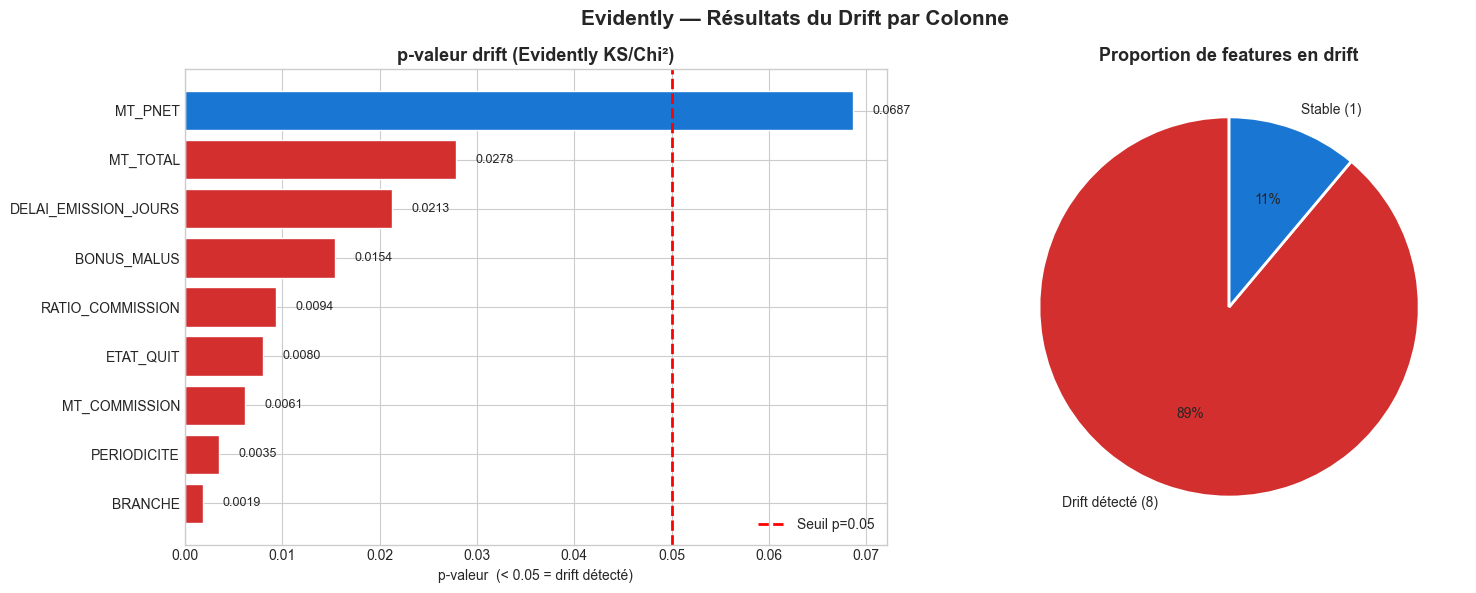

In [230]:
# ── Visualisation Evidently drift scores ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Barplot p-valeurs
ax = axes[0]
p_vals = df_drift.set_index('Colonne')['p-valeur'].astype(float)
colors = [PALETTE[1] if v < 0.05 else PALETTE[0] for v in p_vals]
bars = ax.barh(p_vals.index, p_vals.values, color=colors, edgecolor='white')
ax.axvline(0.05, color='red', linestyle='--', linewidth=2, label='Seuil p=0.05')
ax.set_title('p-valeur drift (Evidently KS/Chi²)', fontsize=13, fontweight='bold')
ax.set_xlabel('p-valeur  (< 0.05 = drift détecté)')
ax.legend()
for bar, val in zip(bars, p_vals.values):
    ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)

# Pie drift / no-drift
ax = axes[1]
n_drift    = (df_drift['Drift ?'].str.contains('OUI')).sum()
n_nodrift  = len(df_drift) - n_drift
ax.pie([n_drift, n_nodrift],
       labels=[f'Drift détecté ({n_drift})', f'Stable ({n_nodrift})'],
       colors=[PALETTE[1], PALETTE[0]], autopct='%1.0f%%',
       startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Proportion de features en drift', fontsize=13, fontweight='bold')

plt.suptitle('Evidently — Résultats du Drift par Colonne', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Drift Glissant — Rapport Evidently par Trimestre

In [231]:
# ── Baseline = premier trimestre disponible ──────────────────────────────
quarters = sorted(emission['TRIMESTRE'].dropna().unique())
first_q   = quarters[0]
baseline_q = emission[emission['TRIMESTRE'] == first_q][NUMERICAL_FEATURES].dropna().copy()

print(f"Référence trimestrielle : {first_q}  ({len(baseline_q):,} lignes)")
print(f"Trimestres à analyser   : {quarters}")

base_def = DataDefinition()
base_ds  = Dataset.from_pandas(
    baseline_q.reset_index(drop=True), data_definition=base_def
)


Référence trimestrielle : 2017Q4  (116 lignes)
Trimestres à analyser   : ['2017Q4', '2018Q1', '2018Q2', '2018Q3', '2018Q4', '2019Q1', '2019Q2', '2019Q3', '2019Q4', '2020Q1', '2020Q2', '2020Q3', '2020Q4', '2021Q1', '2021Q2', '2021Q3', '2021Q4', '2022Q1', '2022Q2', '2022Q3', '2022Q4', '2023Q1', '2023Q2', '2023Q3', '2023Q4', '2024Q1', '2024Q2', '2024Q3', '2024Q4', '2025Q1', '2025Q2', '2025Q3', '2025Q4', 'NaT']


In [232]:
# ── Boucle trimestrielle ─────────────────────────────────────────────────
rolling_results = []

for q in quarters:
    df_q = emission[emission['TRIMESTRE'] == q][NUMERICAL_FEATURES].dropna().copy()
    if len(df_q) < 50:
        continue

    q_def = DataDefinition()
    q_ds  = Dataset.from_pandas(df_q.reset_index(drop=True), data_definition=q_def)

    # Rapport léger — drift uniquement
    q_metrics = [DriftedColumnsCount()] + [ValueDrift(column=c) for c in NUMERICAL_FEATURES]
    q_report  = Report(q_metrics)
    q_snap    = q_report.run(reference_data=base_ds, current_data=q_ds)
    q_dict    = q_snap.dict()['metrics']

    row = {'Trimestre': q, 'N': len(df_q)}
    for m in q_dict:
        name = m['metric_name']
        cfg  = m.get('config', {})
        val  = m['value']
        if name.startswith('DriftedColumnsCount'):
            row['NB_DRIFTED']    = val.get('count', np.nan) if isinstance(val, dict) else val
            row['SHARE_DRIFTED'] = val.get('share', np.nan) if isinstance(val, dict) else np.nan
        elif name.startswith('ValueDrift'):
            col = cfg.get('column', '?')
            row[f'DRIFT_{col}'] = float(val) if isinstance(val, float) else np.nan

    rolling_results.append(row)

df_roll = pd.DataFrame(rolling_results)
print(f"Drift glissant calculé sur {len(df_roll)} trimestres")
df_roll.head()


Drift glissant calculé sur 33 trimestres


,Trimestre,N,NB_DRIFTED,SHARE_DRIFTED,DRIFT_MT_PNET,DRIFT_MT_TOTAL,DRIFT_MT_COMMISSION,DRIFT_RATIO_COMMISSION,DRIFT_BONUS_MALUS,DRIFT_DELAI_EMISSION_JOURS
0,2017Q4,116,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000
1,2018Q1,693,1.0000,0.1667,0.8911,0.7912,0.8399,0.9616,0.8822,0.0000
2,2018Q2,703,1.0000,0.1667,0.4909,0.4689,0.5508,0.9397,0.8843,0.0000
3,2018Q3,745,1.0000,0.1667,0.5809,0.4642,0.5367,0.9625,0.8261,0.0000
4,2018Q4,862,1.0000,0.1667,0.7228,0.5764,0.7032,0.1541,0.9618,0.0000


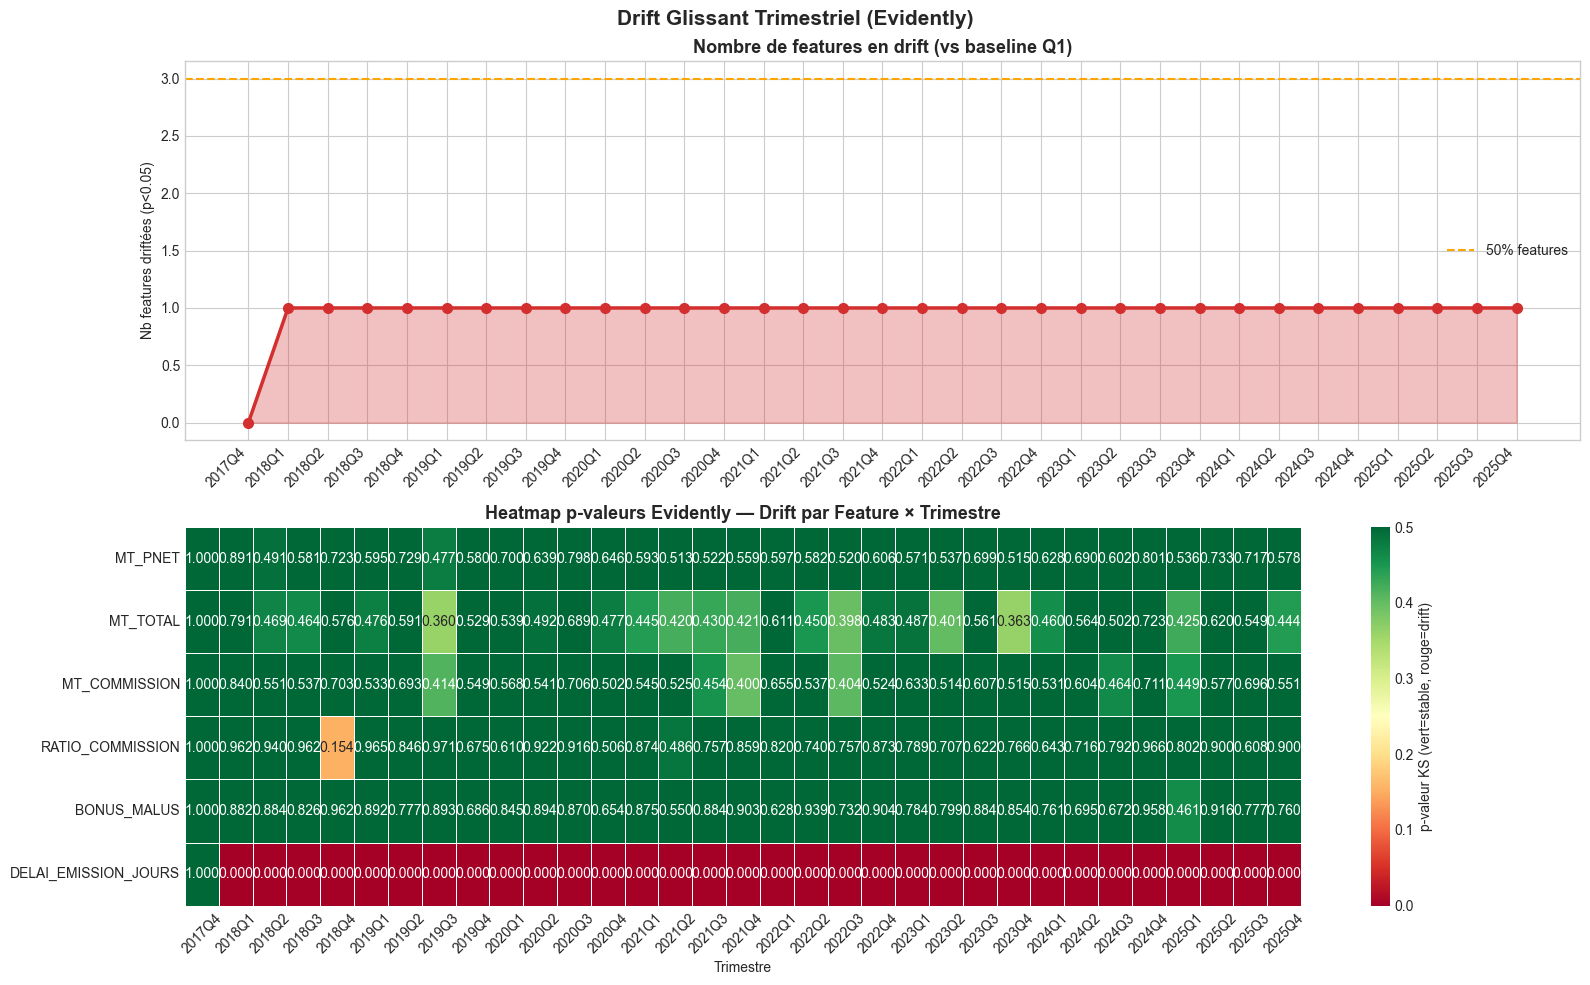

In [233]:
# ── Visualisation drift glissant ─────────────────────────────────────────
drift_cols = [c for c in df_roll.columns if c.startswith('DRIFT_')]

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# 1. Nombre de features en drift par trimestre
ax = axes[0]
ax.fill_between(range(len(df_roll)), df_roll['NB_DRIFTED'].fillna(0),
                alpha=0.3, color=PALETTE[1])
ax.plot(range(len(df_roll)), df_roll['NB_DRIFTED'].fillna(0),
        color=PALETTE[1], linewidth=2.5, marker='o', markersize=7)
ax.set_xticks(range(len(df_roll)))
ax.set_xticklabels(df_roll['Trimestre'], rotation=45, ha='right')
ax.set_title('Nombre de features en drift (vs baseline Q1)', fontsize=13, fontweight='bold')
ax.set_ylabel('Nb features driftées (p<0.05)')
ax.axhline(len(NUMERICAL_FEATURES) * 0.5, color='orange', linestyle='--',
           linewidth=1.5, label='50% features')
ax.legend()

# 2. Heatmap p-valeurs par trimestre
ax = axes[1]
heat_df = df_roll.set_index('Trimestre')[drift_cols].copy()
heat_df.columns = [c.replace('DRIFT_', '') for c in heat_df.columns]
heat_df = heat_df.astype(float)

sns.heatmap(
    heat_df.T,
    ax=ax,
    cmap='RdYlGn',
    vmin=0, vmax=0.5,
    annot=True, fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'p-valeur KS (vert=stable, rouge=drift)'}
)
ax.set_title('Heatmap p-valeurs Evidently — Drift par Feature × Trimestre',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Trimestre')
ax.tick_params(axis='x', rotation=45)

plt.suptitle('Drift Glissant Trimestriel (Evidently)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 7. Analyses Complémentaires — PSI Manuel & KDE

In [234]:
# ── PSI (Population Stability Index) ────────────────────────────────────
def compute_psi(expected, actual, bins=10, eps=1e-6):
    expected, actual = expected.dropna(), actual.dropna()
    breakpoints = np.unique(np.percentile(expected, np.linspace(0, 100, bins + 1)))
    if len(breakpoints) < 3:
        return np.nan
    e_pct = np.histogram(expected, bins=breakpoints)[0] / len(expected) + eps
    a_pct = np.histogram(actual,   bins=breakpoints)[0] / len(actual)   + eps
    e_pct /= e_pct.sum(); a_pct /= a_pct.sum()
    return float(np.sum((a_pct - e_pct) * np.log(a_pct / e_pct)))

psi_rows = []
for col in NUMERICAL_FEATURES:
    if col not in df_baseline.columns:
        continue
    psi_val = compute_psi(df_baseline[col], df_current[col])
    level, _ = psi_level(psi_val) if not np.isnan(psi_val) else ('N/A', '#999')

    # Récupérer le p-val Evidently pour comparaison
    ev_row = df_drift[df_drift['Colonne'] == col]
    ev_p   = float(ev_row['p-valeur'].values[0]) if len(ev_row) else np.nan

    psi_rows.append({
        'Colonne'          : col,
        'PSI'              : psi_val,
        'Niveau PSI'       : level,
        'Evidently p-val'  : ev_p,
        'Evidently Drift?' : '🚨' if ev_p < 0.05 else '✅',
    })

df_psi = pd.DataFrame(psi_rows).sort_values('PSI', ascending=False)
print("PSI vs Evidently — Comparaison des deux approches :")
display(df_psi.round(5))


PSI vs Evidently — Comparaison des deux approches :


,Colonne,PSI,Niveau PSI,Evidently p-val,Evidently Drift?
4,BONUS_MALUS,0.0009,✅ Stable,0.0154,🚨
5,DELAI_EMISSION_JOURS,0.0008,✅ Stable,0.0213,🚨
3,RATIO_COMMISSION,0.0008,✅ Stable,0.0094,🚨
0,MT_PNET,0.0002,✅ Stable,0.0687,✅
2,MT_COMMISSION,0.0002,✅ Stable,0.0061,🚨
1,MT_TOTAL,0.0002,✅ Stable,0.0278,🚨


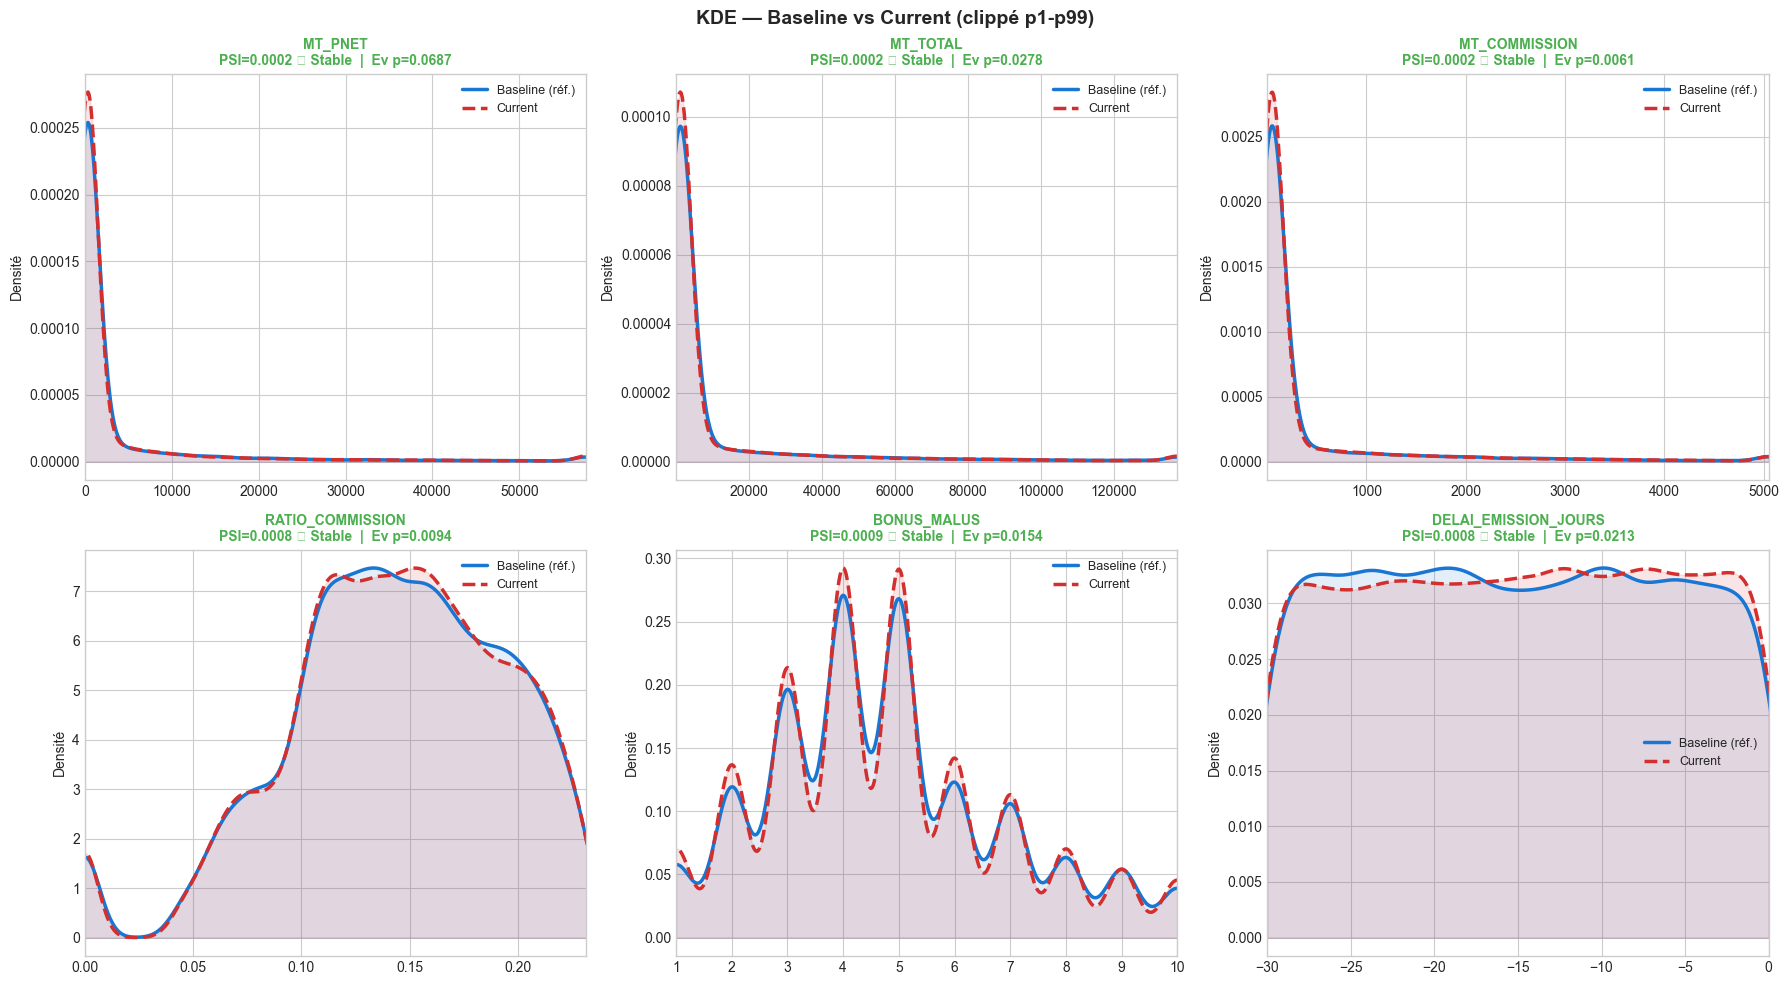

In [235]:
# ── KDE plots — Baseline vs Current ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for (col, ax) in zip(NUMERICAL_FEATURES, axes.flatten()):
    b_vals = df_baseline[col].dropna()
    c_vals = df_current[col].dropna()
    q01, q99 = b_vals.quantile([0.01, 0.99])
    b_clip = b_vals.clip(q01, q99)
    c_clip = c_vals.clip(q01, q99)

    b_clip.plot.kde(ax=ax, color=PALETTE[0], linewidth=2.5, label='Baseline (réf.)')
    c_clip.plot.kde(ax=ax, color=PALETTE[1], linewidth=2.5,
                    linestyle='--', label='Current')

    xs = np.linspace(q01, q99, 300)
    try:
        kde_b = stats.gaussian_kde(b_clip); kde_c = stats.gaussian_kde(c_clip)
        ax.fill_between(xs, kde_b(xs), alpha=0.12, color=PALETTE[0])
        ax.fill_between(xs, kde_c(xs), alpha=0.12, color=PALETTE[1])
    except Exception:
        pass

    # Annoter avec PSI + p-val Evidently
    row = df_psi[df_psi['Colonne'] == col]
    if len(row):
        psi_v = row['PSI'].values[0]
        ev_p  = row['Evidently p-val'].values[0]
        lv, color = psi_level(psi_v)
        ax.set_title(f"{col}\nPSI={psi_v:.4f} {lv}  |  Ev p={ev_p:.4f}",
                 fontsize=10, fontweight='bold', color=color)
    else:
        ax.set_title(col, fontsize=10, fontweight='bold')

    ax.set_ylabel('Densité')
    ax.legend(fontsize=9)
    ax.set_xlim(q01, q99)

plt.suptitle('KDE — Baseline vs Current (clippé p1-p99)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 8. Drift Catégoriel — Chi-Carré + Visualisation

Drift catégoriel :


,Colonne,Chi2 Stat,Chi2 p-val,Drift Chi²?,Evidently p
0,BRANCHE,0.6569,0.7200,✅ NON,0.0019
1,PERIODICITE,2.2263,0.5268,✅ NON,0.0035
2,ETAT_QUIT,12.0874,0.0336,🚨 OUI,0.0080


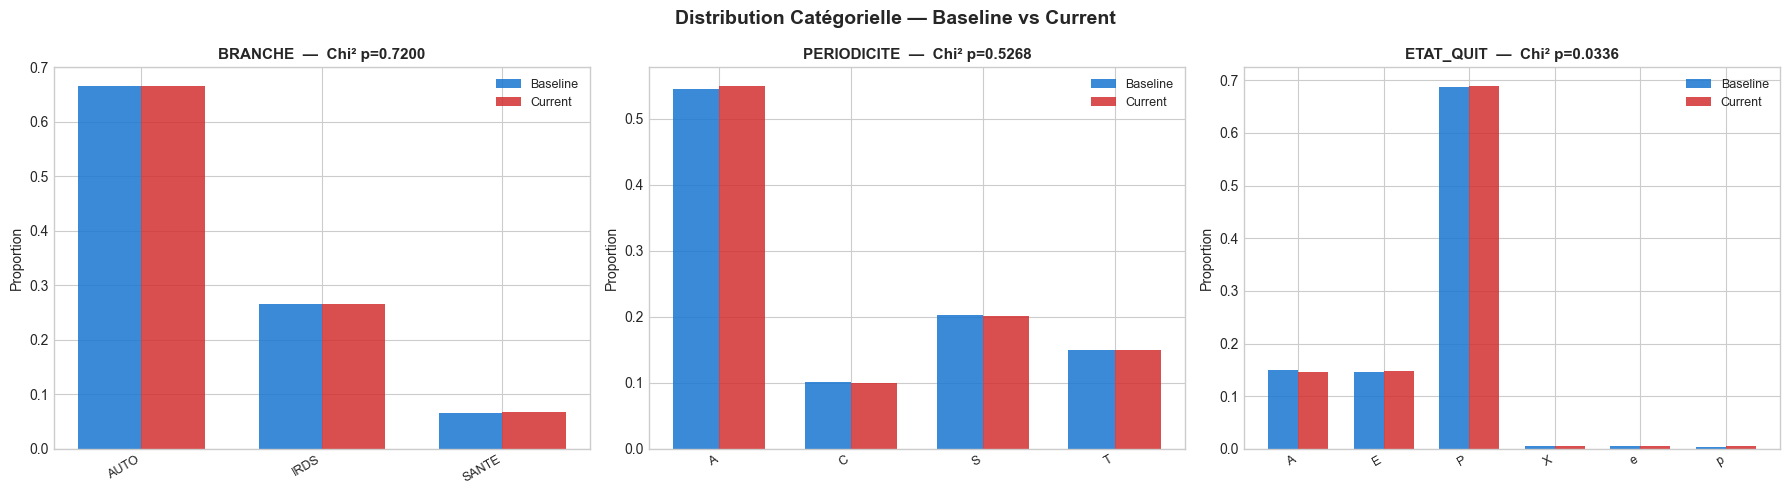

In [236]:
cat_results = []
for col in CATEGORICAL_FEATURES:
    if col not in df_baseline.columns:
        continue
    cats = sorted(set(df_baseline[col].dropna()) | set(df_current[col].dropna()))
    e_cnt = df_baseline[col].value_counts().reindex(cats, fill_value=1).astype(float)
    a_cnt = df_current[col].value_counts().reindex(cats, fill_value=1).astype(float)
    a_scaled = a_cnt * (e_cnt.sum() / a_cnt.sum())
    chi2_stat, chi2_p = stats.chisquare(f_obs=a_scaled, f_exp=e_cnt)

    # Evidently p-val pour comparaison
    ev_row = df_drift[df_drift['Colonne'] == col]
    ev_p   = float(ev_row['p-valeur'].values[0]) if len(ev_row) else np.nan

    cat_results.append({
        'Colonne'    : col,
        'Chi2 Stat'  : chi2_stat,
        'Chi2 p-val' : chi2_p,
        'Drift Chi²?': '🚨 OUI' if chi2_p < 0.05 else '✅ NON',
        'Evidently p': ev_p,
    })

df_cat = pd.DataFrame(cat_results)
print("Drift catégoriel :")
display(df_cat.round(5))

# Barplots comparatifs
fig, axes = plt.subplots(1, len(CATEGORICAL_FEATURES), figsize=(18, 5))
if len(CATEGORICAL_FEATURES) == 1:
    axes = [axes]

for col, ax in zip(CATEGORICAL_FEATURES, axes):
    if col not in df_baseline.columns:
        continue
    cats = sorted(set(df_baseline[col].dropna()) | set(df_current[col].dropna()))
    b_pct = df_baseline[col].value_counts(normalize=True).reindex(cats, fill_value=0)
    c_pct = df_current[col].value_counts(normalize=True).reindex(cats, fill_value=0)

    x = np.arange(len(cats)); w = 0.35
    ax.bar(x - w/2, b_pct.values, w, label='Baseline', color=PALETTE[0], alpha=0.85)
    ax.bar(x + w/2, c_pct.values, w, label='Current',  color=PALETTE[1], alpha=0.85)
    ax.set_xticks(x)
    ax.set_xticklabels(cats, rotation=30, ha='right', fontsize=9)

    row = df_cat[df_cat['Colonne'] == col]
    suffix = f"Chi² p={row['Chi2 p-val'].values[0]:.4f}" if len(row) else ''
    ax.set_title(f"{col}  —  {suffix}", fontsize=11, fontweight='bold')
    ax.set_ylabel('Proportion'); ax.legend(fontsize=9)

plt.suptitle('Distribution Catégorielle — Baseline vs Current',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 9. Évolution Temporelle des KPIs Métier

In [237]:
# ── KPIs mensuels ────────────────────────────────────────────────────────
for etat in ['P', 'A', 'E']:
    emission[f'IS_{etat}'] = (emission['ETAT_QUIT'].str.upper() == etat).astype(int)

monthly = emission.groupby('ANNEE_MOIS').agg(
    NB_QUITTANCES  = ('NUM_QUITTANCE',       'count'),
    MT_PNET_MOY    = ('MT_PNET',             'mean'),
    MT_PNET_MED    = ('MT_PNET',             'median'),
    RATIO_COM_MOY  = ('RATIO_COMMISSION',    'mean'),
    BM_MOY         = ('BONUS_MALUS',         'mean'),
    DELAI_MOY      = ('DELAI_EMISSION_JOURS','mean'),
    TAUX_P         = ('IS_P',                'mean'),
    TAUX_A         = ('IS_A',                'mean'),
    TAUX_E         = ('IS_E',                'mean'),
).reset_index()
monthly['DT'] = monthly['ANNEE_MOIS'].dt.to_timestamp()

# Sinistres mensuels
sinistre['ANNEE_MOIS_S'] = sinistre['DATE_SURVENANCE'].dt.to_period('M')
sin_monthly = sinistre.groupby('ANNEE_MOIS_S').agg(
    NB_SIN   = ('NUM_SINISTRE',   'count'),
    MT_EVAL  = ('MT_EVALUATION',  'mean'),
).reset_index()
sin_monthly['DT'] = sin_monthly['ANNEE_MOIS_S'].dt.to_timestamp()

print(f"KPIs mensuels : {len(monthly)} mois  |  Sinistres : {len(sin_monthly)} mois")


KPIs mensuels : 97 mois  |  Sinistres : 60 mois


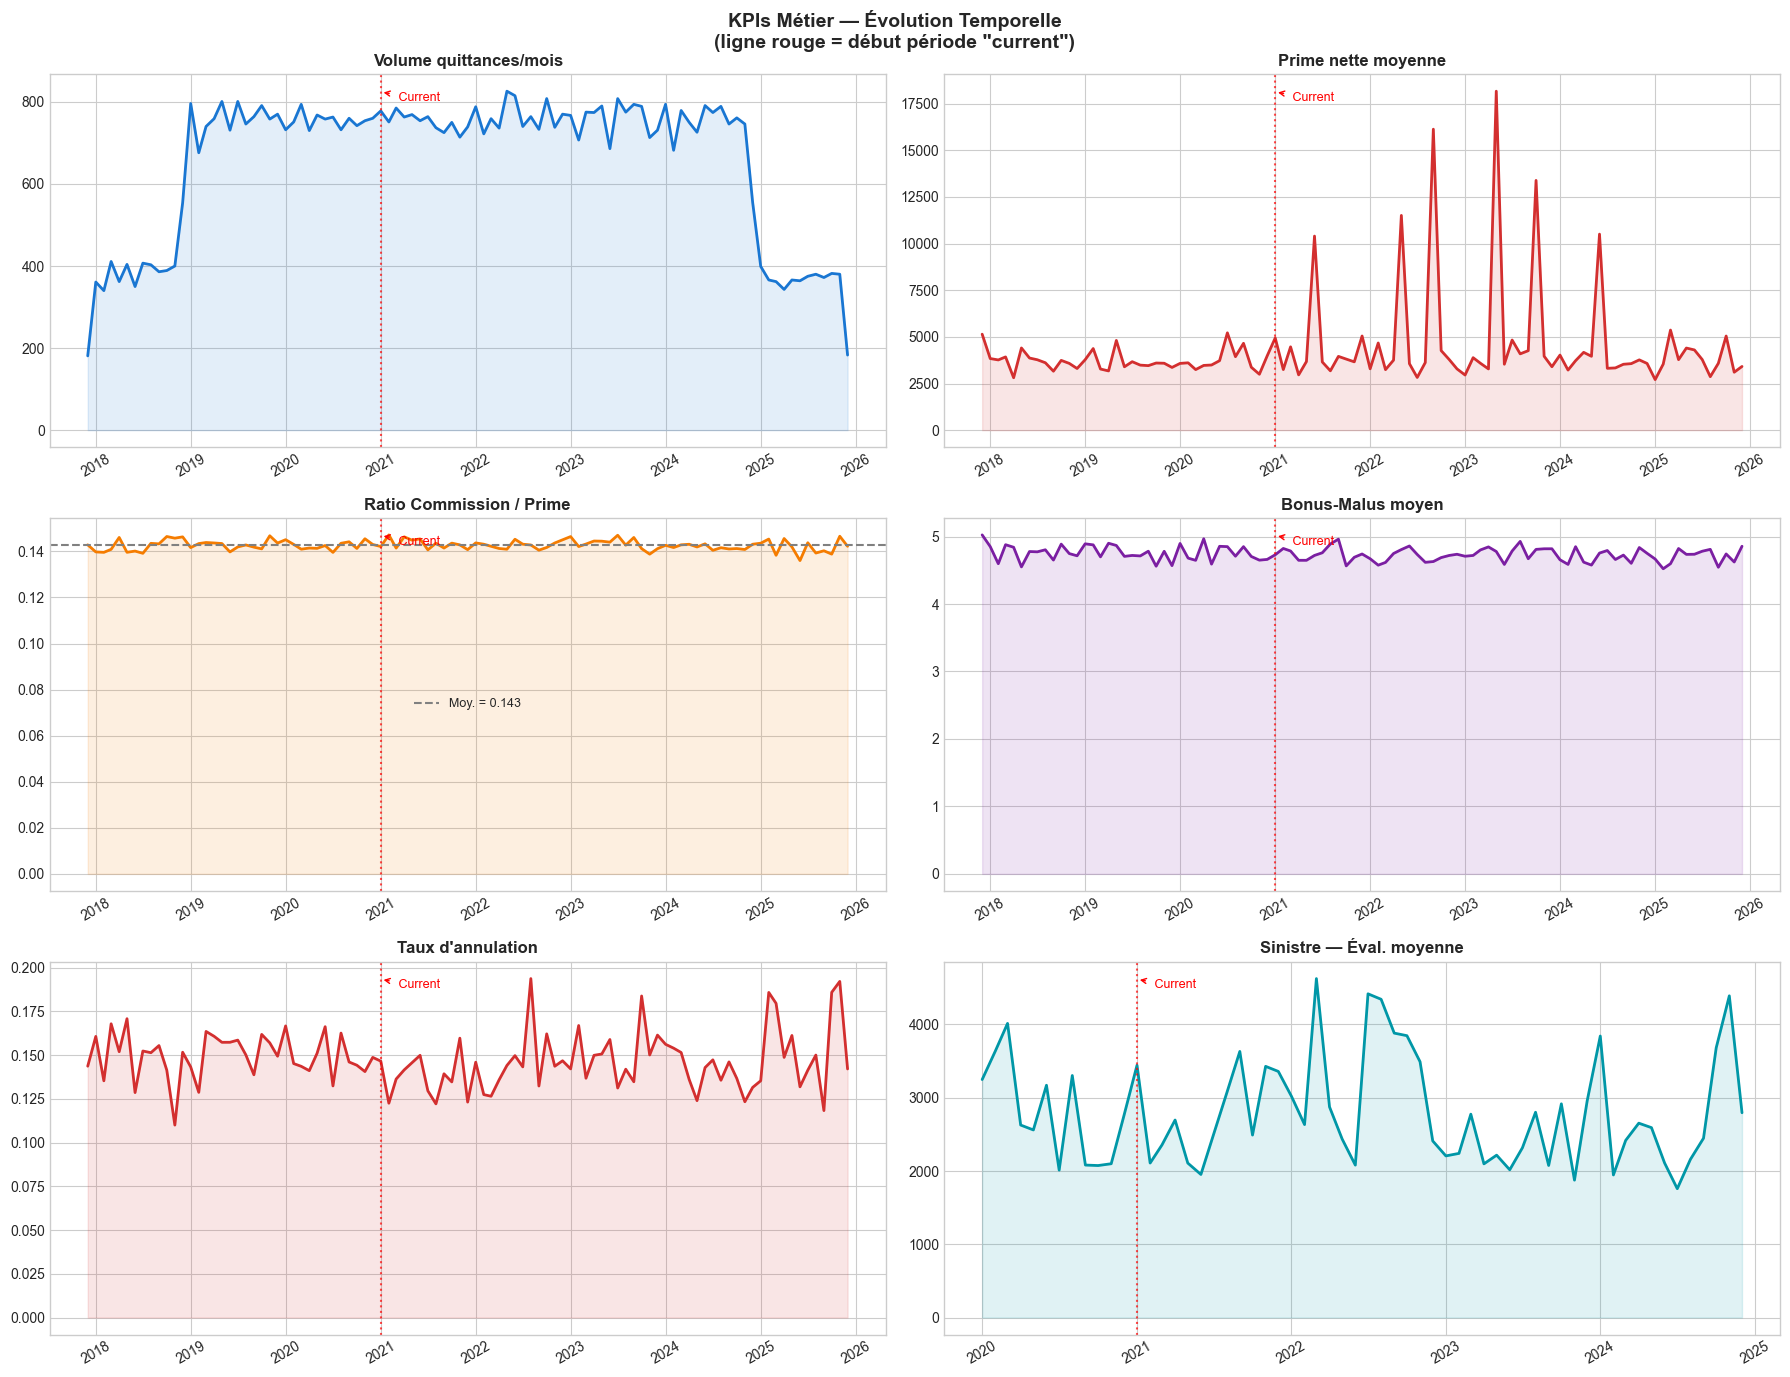

In [238]:
fig, axes = plt.subplots(3, 2, figsize=(18, 14))

plots = [
    (monthly['DT'], monthly['NB_QUITTANCES'],  'Volume quittances/mois',    PALETTE[0], False),
    (monthly['DT'], monthly['MT_PNET_MOY'],    'Prime nette moyenne',       PALETTE[1], False),
    (monthly['DT'], monthly['RATIO_COM_MOY'],  'Ratio Commission / Prime',  PALETTE[3], True),
    (monthly['DT'], monthly['BM_MOY'],         'Bonus-Malus moyen',         PALETTE[4], False),
    (monthly['DT'], monthly['TAUX_A'],         "Taux d'annulation",         PALETTE[1], False),
    (sin_monthly['DT'], sin_monthly['MT_EVAL'],'Sinistre — Éval. moyenne',  PALETTE[5], False),
]

for (x, y, title, color, add_mean), ax in zip(plots, axes.flatten()):
    ax.plot(x, y, color=color, linewidth=2)
    ax.fill_between(x, y, alpha=0.12, color=color)
    if add_mean:
        ax.axhline(y.mean(), color='gray', linestyle='--', linewidth=1.5,
                   label=f'Moy. = {y.mean():.3f}')
        ax.legend(fontsize=9)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=30)

# Ajouter ligne de séparation baseline/current
try:
    cutoff_year = int(float(current_years[0])) if isinstance(current_years[0], (float, str)) else int(current_years[0])
    cutoff_date = pd.Timestamp(f"{cutoff_year}-01-01")
except Exception as e:
    print(f"Erreur lors du parsing de current_years[0]: {current_years[0]} — {e}")
    cutoff_date = None

if cutoff_date is not None:
    for (x, y, _, _, _), ax in zip(plots, axes.flatten()):
        x_vals = pd.Series(x) if not isinstance(x, pd.Series) else x
        idx = x_vals.searchsorted(cutoff_date, side='left')
        if idx < len(x_vals):
            x_annot = x_vals.iloc[idx] if hasattr(x_vals, 'iloc') else x_vals[idx]
        else:
            x_annot = x_vals.iloc[-1] if hasattr(x_vals, 'iloc') else x_vals[-1]
        ax.axvline(cutoff_date, color='red', linestyle=':', linewidth=1.5, alpha=0.7)
        # Use an arrow annotation pointing right to indicate the start of 'current' period
        ax.annotate(' Current', xy=(x_annot, ax.get_ylim()[1]*0.95), xytext=(10, 0), textcoords='offset points',
                    color='red', fontsize=9, va='top', ha='left', arrowprops=dict(arrowstyle='->', color='red'))

plt.suptitle('KPIs Métier — Évolution Temporelle\n(ligne rouge = début période "current")',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Dashboard Synthèse — Toutes Métriques

In [239]:
# ── Compilation synthèse ─────────────────────────────────────────────────
synth_rows = []

# Numériques
for _, row in df_psi.iterrows():
    col = row['Colonne']
    ev_row = df_drift[df_drift['Colonne'] == col]
    ev_p   = float(ev_row['p-valeur'].values[0]) if len(ev_row) else np.nan
    psi_v  = row['PSI']
    lv, _  = psi_level(psi_v) if not np.isnan(psi_v) else ('N/A', '')
    synth_rows.append({
        'Feature'       : col,
        'Type'          : 'Numérique',
        'Evidently p'   : ev_p,
        'Ev. Drift?'    : '🚨' if ev_p < 0.05 else '✅',
        'PSI'           : psi_v,
        'PSI Niveau'    : lv,
        'Score Risque'  : (1 if ev_p < 0.05 else 0) + (1 if psi_v >= PSI_STABLE else 0),
    })

# Catégoriels
for _, row in df_cat.iterrows():
    synth_rows.append({
        'Feature'      : row['Colonne'],
        'Type'         : 'Catégoriel',
        'Evidently p'  : row['Evidently p'],
        'Ev. Drift?'   : '🚨' if row['Chi2 p-val'] < 0.05 else '✅',
        'PSI'          : np.nan,
        'PSI Niveau'   : 'N/A',
        'Score Risque' : 1 if row['Chi2 p-val'] < 0.05 else 0,
    })

df_synth = pd.DataFrame(synth_rows).sort_values('Score Risque', ascending=False)

print("=" * 75)
print("  SYNTHÈSE DRIFT — EVIDENTLY + PSI")
print("=" * 75)
display(df_synth.round(5).style
    .applymap(lambda v: 'background-color:#ffcccc' if '🚨' in str(v) else
                         'background-color:#ccffcc' if '✅' in str(v) else '',
              subset=['Ev. Drift?']))
print("=" * 75)


  SYNTHÈSE DRIFT — EVIDENTLY + PSI


,Feature,Type,Evidently p,Ev. Drift?,PSI,PSI Niveau,Score Risque
0,BONUS_MALUS,Numérique,0.015420,🚨,0.000910,✅ Stable,1
1,DELAI_EMISSION_JOURS,Numérique,0.021320,🚨,0.000850,✅ Stable,1
2,RATIO_COMMISSION,Numérique,0.009400,🚨,0.000790,✅ Stable,1
4,MT_COMMISSION,Numérique,0.006140,🚨,0.000190,✅ Stable,1
5,MT_TOTAL,Numérique,0.027820,🚨,0.000170,✅ Stable,1
8,ETAT_QUIT,Catégoriel,0.008000,🚨,nan,N/A,1
3,MT_PNET,Numérique,0.068680,✅,0.000230,✅ Stable,0
6,BRANCHE,Catégoriel,0.001880,✅,nan,N/A,0
7,PERIODICITE,Catégoriel,0.003470,✅,nan,N/A,0


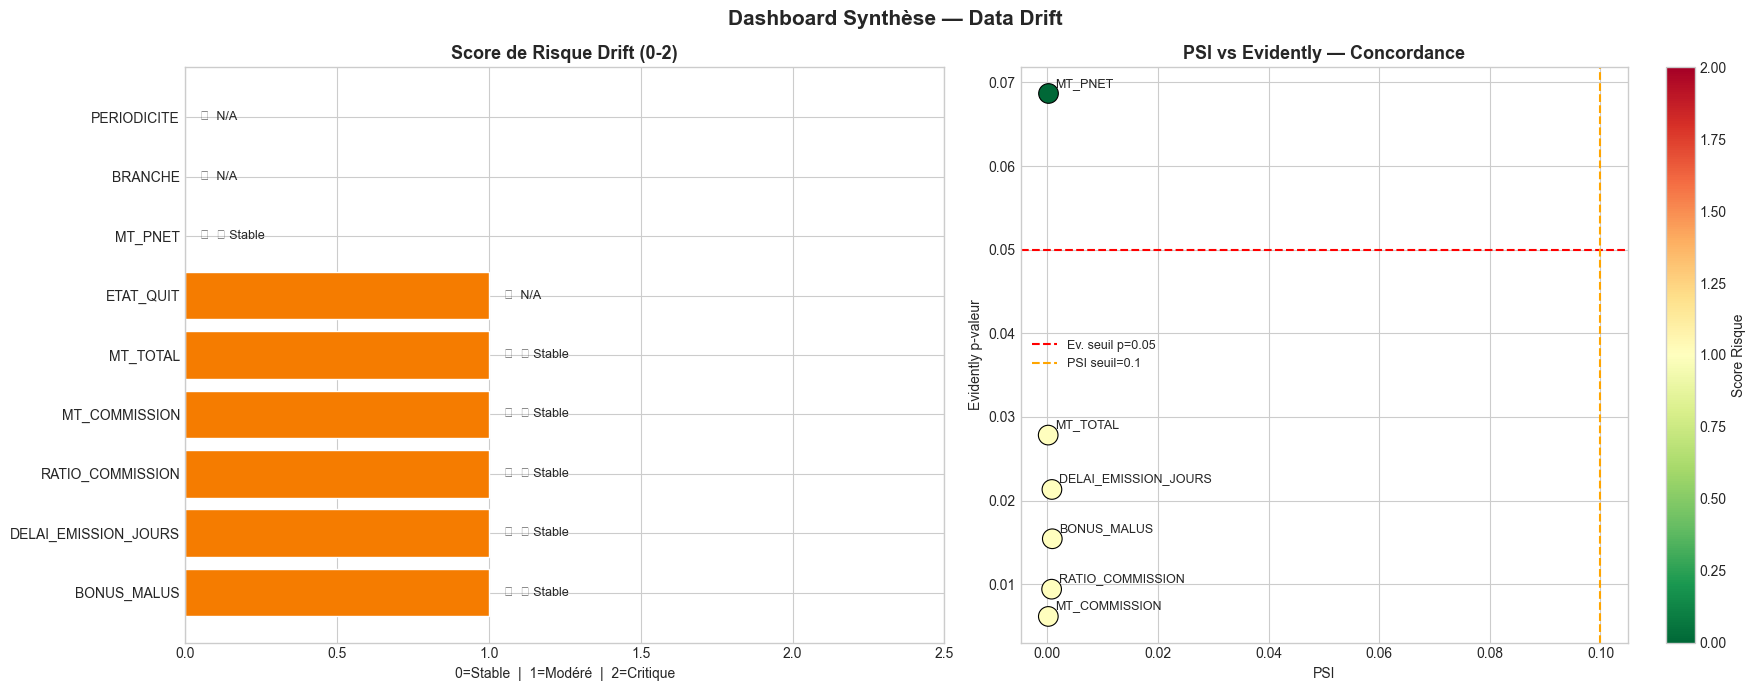

In [240]:
# ── Heatmap synthèse ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Barplot score de risque
ax = axes[0]
colors_bar = [PALETTE[1] if s == 2 else PALETTE[3] if s == 1 else PALETTE[0]
               for s in df_synth['Score Risque']]
ax.barh(df_synth['Feature'], df_synth['Score Risque'],
        color=colors_bar, edgecolor='white')
ax.set_xlim(0, 2.5)
ax.set_title('Score de Risque Drift (0-2)', fontsize=13, fontweight='bold')
ax.set_xlabel('0=Stable  |  1=Modéré  |  2=Critique')
for i, (_, row) in enumerate(df_synth.iterrows()):
    ax.text(row['Score Risque'] + 0.05, i, f"{row['Ev. Drift?']}  {row['PSI Niveau']}",
            va='center', fontsize=9)

# Scatter PSI vs p-valeur Evidently
ax = axes[1]
num_df = df_synth[df_synth['Type'] == 'Numérique'].dropna(subset=['PSI', 'Evidently p'])
sc = ax.scatter(num_df['PSI'], num_df['Evidently p'],
                c=num_df['Score Risque'], cmap='RdYlGn_r',
                s=200, edgecolors='black', linewidths=0.8, vmin=0, vmax=2)
plt.colorbar(sc, ax=ax, label='Score Risque')
ax.axhline(0.05,       color='red',    linestyle='--', linewidth=1.5, label='Ev. seuil p=0.05')
ax.axvline(PSI_STABLE, color='orange', linestyle='--', linewidth=1.5, label=f'PSI seuil={PSI_STABLE}')
for _, row in num_df.iterrows():
    ax.annotate(row['Feature'], (row['PSI'], row['Evidently p']),
                textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.set_xlabel('PSI'); ax.set_ylabel('Evidently p-valeur')
ax.set_title('PSI vs Evidently — Concordance', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)

plt.suptitle('Dashboard Synthèse — Data Drift', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()


## 11. Système d'Alertes & Recommandations

In [241]:
print("=" * 70)
print("  🔔  ALERTES DATA DRIFT — EVIDENTLY AI")
print("=" * 70)

critical, moderate, stable = [], [], []

for _, row in df_synth.iterrows():
    score = row['Score Risque']
    feat  = row['Feature']
    ev_p  = row['Evidently p']
    psi   = row['PSI']

    if score == 2:
        critical.append((feat, ev_p, psi))
        icon = '🚨'
        rec  = 'Réentraîner le modèle IMMÉDIATEMENT'
    elif score == 1:
        moderate.append((feat, ev_p, psi))
        icon = '⚠️'
        rec  = 'Planifier un réentraînement dans les 30 jours'
    else:
        stable.append((feat, ev_p, psi))
        icon = '✅'
        rec  = 'Aucune action requise'

    psi_str = f"PSI={psi:.4f}" if not (isinstance(psi, float) and np.isnan(psi)) else "PSI=N/A"
    p_str   = f"p={ev_p:.4f}" if not (isinstance(ev_p, float) and np.isnan(ev_p)) else "p=N/A"
    print(f"  {icon}  {feat:<30}  {p_str}  {psi_str:<15}  →  {rec}")

print("=" * 70)
print(f"  🚨 Critique : {len(critical)}")
print(f"  ⚠️  Modéré  : {len(moderate)}")
print(f"  ✅ Stable   : {len(stable)}")
print("=" * 70)


  🔔  ALERTES DATA DRIFT — EVIDENTLY AI
  ⚠️  BONUS_MALUS                     p=0.0154  PSI=0.0009       →  Planifier un réentraînement dans les 30 jours
  ⚠️  DELAI_EMISSION_JOURS            p=0.0213  PSI=0.0008       →  Planifier un réentraînement dans les 30 jours
  ⚠️  RATIO_COMMISSION                p=0.0094  PSI=0.0008       →  Planifier un réentraînement dans les 30 jours
  ⚠️  MT_COMMISSION                   p=0.0061  PSI=0.0002       →  Planifier un réentraînement dans les 30 jours
  ⚠️  MT_TOTAL                        p=0.0278  PSI=0.0002       →  Planifier un réentraînement dans les 30 jours
  ⚠️  ETAT_QUIT                       p=0.0080  PSI=N/A          →  Planifier un réentraînement dans les 30 jours
  ✅  MT_PNET                         p=0.0687  PSI=0.0002       →  Aucune action requise
  ✅  BRANCHE                         p=0.0019  PSI=N/A          →  Aucune action requise
  ✅  PERIODICITE                     p=0.0035  PSI=N/A          →  Aucune action requise
  🚨 Critiq

## 12. Export des Résultats

In [242]:
# HTML Evidently (rapport interactif complet)
HTML_PATH = "evidently_data_drift_report.html"
snapshot.save_html(HTML_PATH)

